# Linking vegetation data to Nesting and Breeding brids

In [7]:
import os
import numpy as np
import pandas as pd

folder = 'C:/Users/PangY/OneDrive - Smithsonian Institution/Bustard/01_Data/Reneco/Ecology'
df_nest_loc = pd.read_csv(os.path.join(folder, 'Nests_Locations_Morocco.csv'))
df_nest_loc.head()

,Nest_Name,Nest_Latitude,Nest_Longitude,Year_Discovered,Number_Of_Items,Camera_trap_deployed
0,96N01,32.834,-3.996,1996,3.0,No
1,96N02,33.130,-3.711,1996,3.0,No
2,96N03,32.819,-4.031,1996,3.0,No
3,96N04,33.281,-3.863,1996,3.0,No
4,96N05,33.284,-3.968,1996,3.0,No


In [8]:
year_counts = df_nest_loc['Year_Discovered'].value_counts().sort_index()
print(year_counts)

Year_Discovered
1996      10
1997      36
1998       3
1999       1
2000       1
2001      30
2002      89
2003     165
2004     398
2005     101
2006     508
2007     576
2008     624
2009     682
2010     821
2011    1175
2012    1235
2013     859
2014     559
2015    1135
2016    1099
2017    1475
2018     471
2019    1823
2020     268
2021     824
2022     218
2023     501
2024     190
2025     815
Name: count, dtype: int64


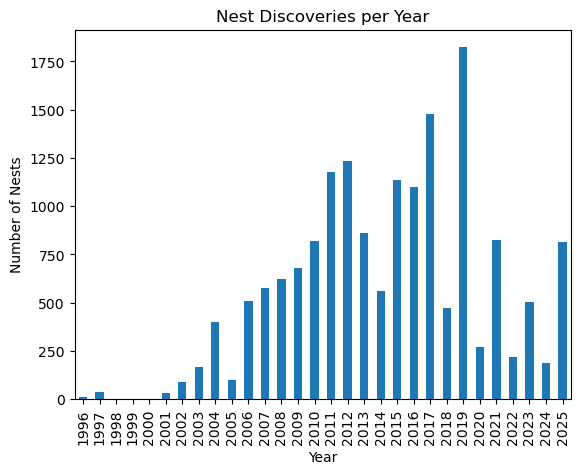

In [9]:
import matplotlib.pyplot as plt

year_counts.sort_index().plot(kind='bar')
plt.xlabel('Year')
plt.ylabel('Number of Nests')
plt.title('Nest Discoveries per Year')
plt.show()

In [11]:
traking_folder = 'C:/Users/PangY/OneDrive - Smithsonian Institution/Bustard/07_Bustard-Project/Dec 2025 - Tracking Data/Data_Houbara_251202'
df_nest = pd.read_csv(os.path.join(traking_folder, 'Table_Nest_Details.csv'))
df_nest.head()

,Nest_Code,Nest_Latitude,Nest_Longitude,Station_ID,Station_Date,Field_Activity,Experimentation,Clutch_Description,Total_Items,Alive_Chick,Dead_Chick,Total_Chicks,Female_ID
0,03N23E,33.13919,-4.01889,28727,2003-05-26 15:26:00,Nest monitoring,NaN,Egg(s),2,0,NaN,0,13826
1,03N23E,33.13919,-4.01889,41268,2003-05-28 18:52:00,Bird trapping,NaN,Empty,0,0,NaN,0,13826
2,03N23E,33.13919,-4.01889,106814,2003-05-27 17:10:00,Nest monitoring,NaN,Egg(s),2,0,NaN,0,13826
3,04N08P,33.12189,-3.71806,19191,2004-03-18,Nest monitoring,NaN,Unknown,0,0,NaN,0,13770
4,04N08P,33.12189,-3.71806,22053,2004-03-19 11:12:00,Nest monitoring,NaN,Egg(s),3,0,NaN,0,13770


In [17]:
n_females = df_nest['Female_ID'].nunique()
print("Number of unique females:", n_females)

n_nests = df_nest['Nest_Code'].nunique()
print("Number of unique nests:", n_nests)

Number of unique females: 205
Number of unique nests: 712


In [19]:
female_ids_sorted = sorted(df_nest['Female_ID'].dropna().unique())
print(female_ids_sorted)

# female_ids_df = pd.DataFrame(female_ids_sorted, columns=['Female_ID'])
# print(female_ids_df)

[36, 85, 683, 728, 760, 916, 1574, 1689, 3537, 3911, 4331, 5221, 5263, 6410, 9046, 11351, 12383, 13742, 13770, 13826, 13838, 13862, 15117, 16074, 16095, 30520, 44143, 58887, 61112, 63300, 66019, 68551, 68607, 69039, 70372, 70473, 70655, 70778, 76029, 83176, 85611, 86711, 87522, 93544, 96842, 97683, 98153, 99147, 99182, 99346, 99459, 103042, 103151, 103155, 103757, 303812, 305091, 305135, 308682, 309753, 309754, 310064, 310080, 312363, 313417, 318186, 318192, 318194, 318197, 318200, 318201, 318206, 318215, 318217, 318227, 318239, 318242, 318273, 318278, 318290, 318305, 318312, 318332, 318376, 318448, 323714, 323722, 323810, 323814, 323819, 323821, 323832, 323834, 323836, 323837, 323839, 323848, 323852, 324842, 326330, 326605, 329663, 329972, 329975, 329999, 337674, 338601, 338929, 345809, 349141, 354896, 355413, 355431, 356096, 356111, 358039, 358132, 358235, 358279, 358416, 358420, 358421, 358422, 369204, 369232, 369233, 369312, 371858, 371863, 371871, 371877, 371882, 371883, 371893, 3

In [20]:
traking_folder = 'C:/Users/PangY/OneDrive - Smithsonian Institution/Bustard/07_Bustard-Project/Dec 2025 - Tracking Data/Data_Houbara_251202'
df_track = pd.read_csv(os.path.join(traking_folder, 'Table_Automatic_Data.csv'))
df_track.head()

C:\Users\PangY\AppData\Local\Temp\ipykernel_47820\770363756.py:2: DtypeWarning: Columns (8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  df_track = pd.read_csv(os.path.join(traking_folder, 'Table_Automatic_Data.csv'))


,Individual_ID,Location_ID,Location_Data_Type,Location_Date,Location_Latitude,Location_Longitude,Location_Precision,Location_Elevation,Location_Class,Sensor_Identifier_At_Location,Sensor_Company_At_Location,Sensor_Type_At_Location,day,hour
0,13823,1366850,GPS,2015-04-17 01:06:21,33.25513,-3.84534,7.0,849.0,NaN,273,"Microwave Telemetry, Inc",GSM,NaN,NaN
1,13823,1366999,GPS,2015-04-17 11:00:07,33.25388,-3.84087,5.0,834.0,NaN,273,"Microwave Telemetry, Inc",GSM,NaN,NaN
2,13823,1367253,GPS,2015-04-18 02:51:55,33.25463,-3.84524,10.0,841.0,NaN,273,"Microwave Telemetry, Inc",GSM,NaN,NaN
3,13823,1367298,GPS,2015-04-18 06:19:53,33.25421,-3.84454,8.0,841.0,NaN,273,"Microwave Telemetry, Inc",GSM,NaN,NaN
4,13823,1367323,GPS,2015-04-18 07:20:50,33.25341,-3.84393,16.0,839.0,NaN,273,"Microwave Telemetry, Inc",GSM,NaN,NaN


In [32]:
df_track['Location_Date'] = pd.to_datetime(df_track['Location_Date'],format='mixed',errors='coerce')

df_track['year'] = df_track['Location_Date'].dt.year
df_track['month'] = df_track['Location_Date'].dt.month
df_track['hour'] = df_track['Location_Date'].dt.hour
df_track['doy'] = df_track['Location_Date'].dt.dayofyear

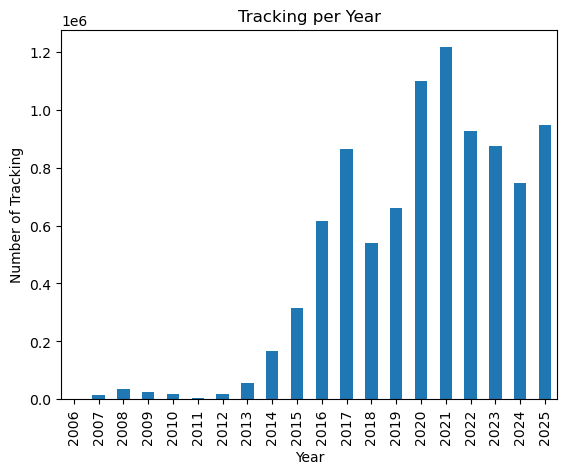

In [35]:
track_year_counts = df_track['year'].value_counts().sort_index()
# print(track_year_counts)

import matplotlib.pyplot as plt

track_year_counts.sort_index().plot(kind='bar')
plt.xlabel('Year')
plt.ylabel('Number of Tracking')
plt.title('Tracking per Year')
plt.show()

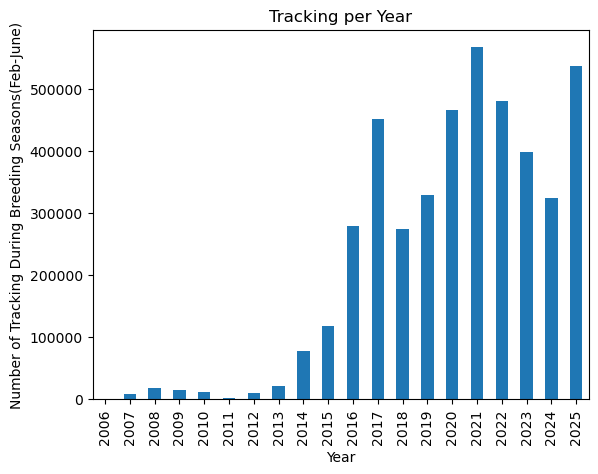

In [36]:
df_track['month'] = df_track['Location_Date'].dt.month
df_breeding = df_track[df_track['month'].between(2, 6)]  #Feb-June

track_breding_year_counts = df_breeding['year'].value_counts().sort_index()
track_breding_year_counts.sort_index().plot(kind='bar')
plt.xlabel('Year')
plt.ylabel('Number of Tracking During Breeding Seasons(Feb-June)')
plt.title('Tracking per Year')
plt.show()

In [39]:
print(df_breeding.columns.tolist())

['Individual_ID', 'Location_ID', 'Location_Data_Type', 'Location_Date', 'Location_Latitude', 'Location_Longitude', 'Location_Precision', 'Location_Elevation', 'Location_Class', 'Sensor_Identifier_At_Location', 'Sensor_Company_At_Location', 'Sensor_Type_At_Location', 'day', 'hour', 'year', 'month', 'doy']


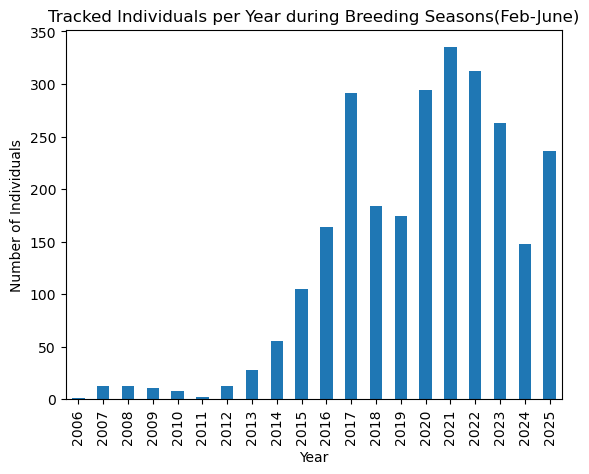

In [44]:
# track_breding_ID_counts = df_breeding['Individual_ID'].value_counts().sort_index()
track_breeding_ID_counts = df_breeding.groupby('year')['Individual_ID'].nunique()

track_breeding_ID_counts.sort_index().plot(kind='bar')
plt.xlabel('Year')
plt.ylabel('Number of Individuals')
plt.title('Tracked Individuals per Year during Breeding Seasons(Feb-June)')
plt.show()

In [30]:
print(df_breeding.shape) #(4385399, 16)

(4385399, 16)


In [21]:
print(df_track.shape) #(9149704, 14)

(9149704, 14)


In [31]:
# df_track_filtered = df_track[df_track['Individual_ID'].isin(female_ids_sorted)]
df_breeding_filtered = df_breeding[df_breeding['Individual_ID'].isin(female_ids_sorted)]

print(df_breeding_filtered.shape)
df_breeding_filtered.head() #(2748944, 14) to (1205147, 16)

(1205147, 16)


,Individual_ID,Location_ID,Location_Data_Type,Location_Date,Location_Latitude,Location_Longitude,Location_Precision,Location_Elevation,Location_Class,Sensor_Identifier_At_Location,Sensor_Company_At_Location,Sensor_Type_At_Location,day,hour,year,month
16962,5221,1374292,Argos,2015-04-16 18:47:08,33.23712,-3.70624,10.0,902.0,3,144210,"Microwave Telemetry, Inc",Satellite,NaN,18,2015,4
16963,5221,1374327,GPS,2015-04-19 02:00:00,33.24550,-3.78033,10.0,820.0,NaN,144210,"Microwave Telemetry, Inc",Satellite,NaN,2,2015,4
16964,5221,1374333,GPS,2015-04-20 02:00:00,33.26833,-3.87133,10.0,900.0,NaN,144210,"Microwave Telemetry, Inc",Satellite,NaN,2,2015,4
16969,5221,1374343,Argos,2015-04-21 16:07:37,33.26253,-3.88988,10.0,941.0,1,144210,"Microwave Telemetry, Inc",Satellite,NaN,16,2015,4
16970,5221,1374353,GPS,2015-04-21 10:00:00,33.25400,-3.90783,10.0,920.0,NaN,144210,"Microwave Telemetry, Inc",Satellite,NaN,10,2015,4


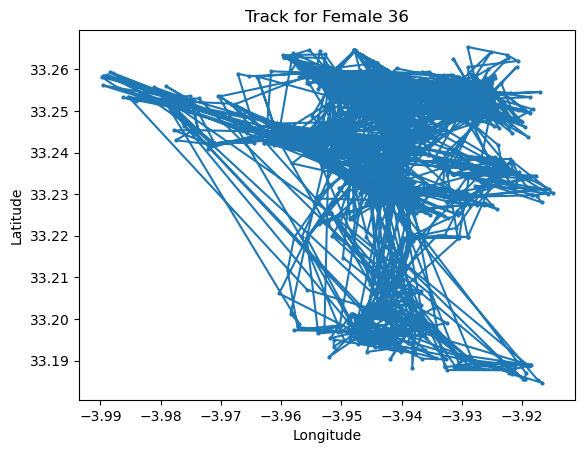

In [45]:
import matplotlib.pyplot as plt

# pick one individual
female_id = female_ids_sorted[0]

# df_one = df_track_filtered[df_track_filtered['Individual_ID'] == female_id]
df_one = df_breeding_filtered[df_breeding_filtered['Individual_ID'] == female_id]

plt.figure()
plt.plot(df_one['Location_Longitude'], df_one['Location_Latitude'], marker='o', markersize=2)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title(f'Track for Female {female_id}')
plt.show()

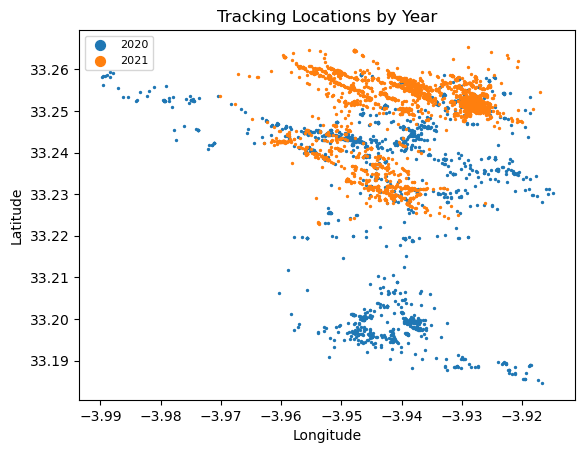

In [47]:
plt.figure()

for year, group in df_one.groupby('year'):
    plt.scatter(
        group['Location_Longitude'],
        group['Location_Latitude'],
        s=2,
        label=year
    )

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Tracking Locations by Year')
plt.legend(markerscale=5, fontsize=8)
plt.show()

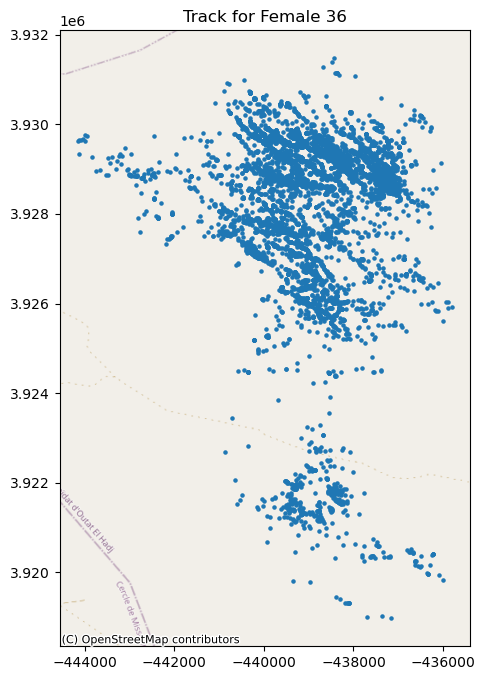

In [25]:
import geopandas as gpd
from shapely.geometry import Point
import contextily as ctx

# convert to GeoDataFrame
gdf = gpd.GeoDataFrame(
    df_one,
    geometry=gpd.points_from_xy(df_one['Location_Longitude'], df_one['Location_Latitude']),
    crs="EPSG:4326"
)

# project to Web Mercator (required for basemap)
gdf = gdf.to_crs(epsg=3857)

ax = gdf.plot(figsize=(8, 8), markersize=5)

# add basemap
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

plt.title(f'Track for Female {female_id}')
plt.show()

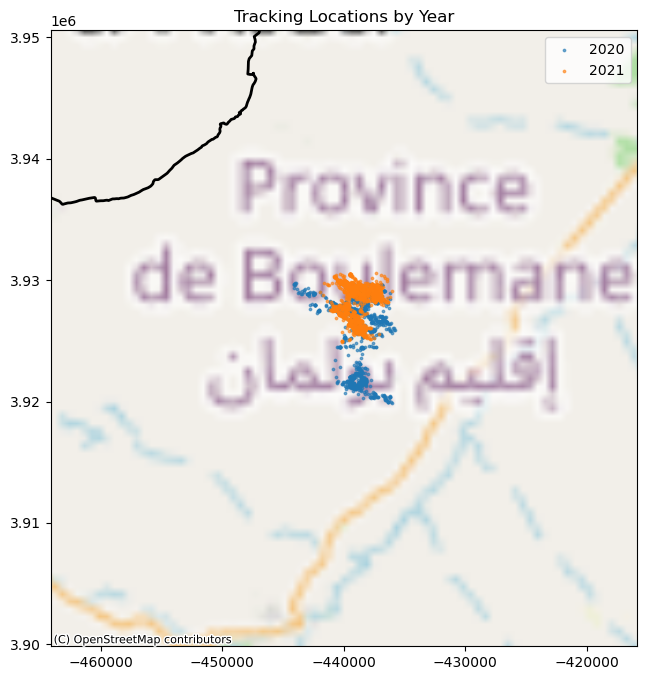

In [51]:
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx

# Convert your data to GeoDataFrame
gdf = gpd.GeoDataFrame(
    df_one,
    geometry=gpd.points_from_xy(df_one['Location_Longitude'],
                                df_one['Location_Latitude']),
    crs="EPSG:4326"
)

# Re-projection
gdf = gdf.to_crs(epsg=3857)

# Load working area
shp_folder = 'C:/Users/PangY/OneDrive - Smithsonian Institution/Bustard/01_Data/Morocco two study areas'
working_area = gpd.read_file(
    os.path.join(shp_folder, 'Eastern_Morocco_Working_Area.shp')
).to_crs(epsg=3857)

# Plot by year + basemap
fig, ax = plt.subplots(figsize=(8, 8))

for year, group in gdf.groupby('year'):
    group.plot(
        ax=ax,
        markersize=3,
        label=year,
        alpha=0.6
    )

# Plot working area boundary (BEFORE show)
working_area.boundary.plot(ax=ax, color='black', linewidth=2)

# Add basemap
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

# Set extent
xmin, ymin, xmax, ymax = gdf.total_bounds
buffer = 20000
ax.set_xlim(xmin - buffer, xmax + buffer)
ax.set_ylim(ymin - buffer, ymax + buffer)

# Final touches
ax.set_title('Tracking Locations by Year')
ax.legend()

plt.show()
